Hedgers
```
BRIAN WEE JOON LI
HU ZIHAO
JI NIAN
YAN TONGSHU
ZHOU XUAN
```

In [24]:
#@title
# This is to download pre-trained word vectors:

# !wget http://nlp.stanford.edu/data/glove.6B.zip
# !unzip -q glove.6B.zip

# You can comment it out later

# Notebook 5 - Pretrained GloVe

This is a graded group assignment. After you are done, please share the link to your assignment with Fedor for grading.

In [25]:
#@title
# Libraries:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras

import re                                  # library for regular expression operations
import string                              # for string operations
from nltk.tokenize import TweetTokenizer

# Part 1

Here we download pretrained GloVe and explore word vectors. Some useful functions will be provided for you.

In [26]:
# Word vectors:

path_to_glove_file = "glove.6B.100d.txt"

embeddings_index = {}
with open(path_to_glove_file) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

print("Found %s word vectors." % len(embeddings_index))

Found 400000 word vectors.


We have created a Python dictionary with words as keys and word vectors as values.

In [27]:
print("Type of the variable with word embeddings is", type(embeddings_index), "\n")
print("Here are the first 10 keys")
print(list(embeddings_index.keys())[:10], "\n")
print("First 5 entries of the vector v('engineer'):")
print(embeddings_index.get('engineer', 0)[:5])

Type of the variable with word embeddings is <class 'dict'> 

Here are the first 10 keys
['the', ',', '.', 'of', 'to', 'and', 'in', 'a', '"', "'s"] 

First 5 entries of the vector v('engineer'):
[-0.22299 -0.50327 -0.1059  -0.12002  0.5725 ]


Note that we can access dictionary elements via either
`dict[key]` or `dict.get(key, alt)`. The first method will produce an error if the key is not in the dictionary. The second method will return `alt` if the key is not in the dictionary.

The cosine similarity between two vectors $x$ and $y$ is
$$
\cos\alpha = \frac{x\cdot y}{\|x\|\cdot \|y\|}
$$

In [28]:
def cosine_sim(x, y):
    return np.dot(x, y) / np.sqrt(np.dot(x, x) * np.dot(y, y))

print("Cosine similarity between 'school' and 'university' is ", \
      cosine_sim(embeddings_index['school'], embeddings_index['university']))

print("Cosine similarity between 'school' and 'indigo' is ", \
      cosine_sim(embeddings_index['school'], embeddings_index['indigo']))

Cosine similarity between 'school' and 'university' is  0.7548451
Cosine similarity between 'school' and 'indigo' is  0.077232435


Now we will print the top 10 words most similar to "school". Note that the first of them is "school" itself.

In [29]:
df = pd.DataFrame(data = embeddings_index.keys(), columns = ["word"])

similarities_with_school = np.zeros(df.shape[0])

count = 0
for w in embeddings_index:
    v = embeddings_index.get(w)
    similarities_with_school[count] = cosine_sim(v, embeddings_index['school'])
    count += 1

df['similarity to school'] = similarities_with_school
df = df.sort_values('similarity to school', ascending = False)
df.head(10)

,word,similarity to school
164,school,1.000000
499,college,0.884787
888,schools,0.835755
4808,elementary,0.815614
543,students,0.802956
1283,student,0.781179
2554,campus,0.769327
3482,graduate,0.769190
221,university,0.754845
2513,teacher,0.754556


# Part 2

Here we will download some text data into Python and work with it.

In [30]:
# Here we download "The Financier" by Theodore Dreiser

!wget https://www.gutenberg.org/files/1840/1840-0.txt
!ls

--2025-01-21 18:55:13--  https://www.gutenberg.org/files/1840/1840-0.txt
Resolving www.gutenberg.org (www.gutenberg.org)... 152.19.134.47, 2610:28:3090:3000:0:bad:cafe:47
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1153597 (1.1M) [text/plain]
Saving to: ‘1840-0.txt.1’

1840-0.txt.1        100%[===================>]   1.10M  5.97MB/s    in 0.2s    

2025-01-21 18:55:14 (5.97 MB/s) - ‘1840-0.txt.1’ saved [1153597/1153597]

1840-0.txt    glove.6B.100d.txt  glove.6B.300d.txt  glove.6B.zip
1840-0.txt.1  glove.6B.200d.txt  glove.6B.50d.txt   sample_data


In [31]:
with open("1840-0.txt","r") as f:
    financier = f.readlines()

print("Sample of the book:")
print(financier[500:504])
print("The type of the data is", type(financier))
print("The book has", len(financier), "lines")

Sample of the book:
['back yard.\n', '\n', '“Well, this is pleasant enough,” he observed, noting a large elm and\n', 'seeing that the yard was partially paved with brick and enclosed within\n']
The type of the data is <class 'list'>
The book has 20162 lines


Now we can extract lines of text and find cosine similarity between any query and a line of the text to be able to pick lines with the highest cosine similarity with our query.

For example, if we look for anything related to "stock market crash" in the book, we can comupute the word vector
$$
v(\mbox{"stock"})+v(\mbox{"market"})+v(\mbox{"crash"})
$$
and find its cosine similarity with all the lines of the book.

In [32]:
query = "Stock market crash"

def split_text(t):
    """Split text function.
    Input:
        t: a string
    Output:
        tokenized_t: a list of words contained in the input text

    """
    # remove stock market tickers like $GE
    t = re.sub(r'\$\w*', '', t)
    # remove old style retweet text "RT"
    t = re.sub(r'^RT[\s]+', '', t)
    # remove hyperlinks
    t = re.sub(r'https?://[^\s\n\r]+', '', t)
    # remove hashtags
    # only removing the hash # sign from the word
    t = re.sub(r'#', '', t)
    # tokenize tweets
    tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,
                               reduce_len=True)
    text_tokens = tokenizer.tokenize(t)

    return text_tokens

def text_to_vector(t):
    v = 0
    for word in split_text(t):
        v = v + embeddings_index.get(word, 0)
    return(v)

print("The query is", query)
vec_query = text_to_vector(query)
print("Vectorized query is", vec_query[:5])

similarities_with_query = np.zeros(len(financier))
for i in range(len(financier)):
    cur_line = financier[i]
    vec_line = text_to_vector(cur_line)
    if (np.any(vec_line == 0)):
        similarities_with_query[i] = 0
    else:
        similarities_with_query[i] = cosine_sim(vec_line, vec_query)

df_financier = pd.DataFrame(data = financier, columns = ["text"])
df_financier['similarity with query'] = similarities_with_query
df_financier = df_financier.sort_values('similarity with query', ascending = False)
df_financier.head(5)

The query is Stock market crash
Vectorized query is [ 1.272929    0.66025996  1.290144    0.0963657  -1.0346301 ]


,text,similarity with query
6212,"prospectus and later annual reports, and to bo...",0.811493
19544,"brokers, and speculators. The stock exchange h...",0.805289
7691,Street Railway shares he could probably replac...,0.793179
1767,noticeable rise or decline in a stock or a gro...,0.792407
6183,"advisable, a simultaneous attack in the stock ...",0.781240


# Your work

Please insert your codes and your explanations below - they will be graded.

## Question 1

Identify words most similar to the word "finance". You can just use Fedor's code above, but you will get a higher grade if you figure out how to vectorize the code, i.e., if you compute similarities of "finance" to all the words in the vocabulary via matrix multiplication. It should be much faster than the explicit loop.

In [34]:
def q1(word: str, embeddings_index: dict) -> pd.DataFrame:


    word_vector = embeddings_index.get(word, None)
    if word_vector is None:
        raise ValueError(f"The word '{word}' is not in the vocabulary.")

    words = list(embeddings_index.keys())
    word_vectors = np.array([embeddings_index[w] for w in words])

    dot_products = word_vectors.dot(word_vector)

    norms = np.linalg.norm(word_vectors, axis=1) * np.linalg.norm(word_vector)

    # Compute cosine similarities
    cosine_similarities = dot_products / norms

    # Create a DataFrame of the results
    similarity_df = pd.DataFrame({
        'word': words,
        'similarity_to_' + word: cosine_similarities
    })

    # Sort by similarity in descending order
    similarity_df = similarity_df.sort_values(by='similarity_to_' + word, ascending=False)

    return similarity_df

In [35]:
query_word = "finance"
similarity_df = q1(query_word, embeddings_index)
print(similarity_df.head(10))

            word  similarity_to_finance
1179     finance               1.000000
2128     banking               0.719348
205      foreign               0.703172
141     minister               0.695988
395    financial               0.685117
2302    commerce               0.666763
783   investment               0.660580
1296      reform               0.655648
78    government               0.655049
872         fund               0.653581


## Question 2

Visualize "The Financier". You will get a higher score if you manage to plot a word cloud.

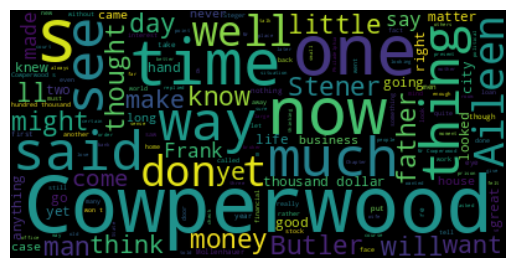

In [36]:
!pip install wordcloud
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

F = ' '.join(financier)
wordcloud = WordCloud().generate(F)

# Visualize the word cloud
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()

## Question 3

Find lines of "The Fiancier" most similar to the query "New York Stock Exchange". You will get a higher score if you manage to re-write Fedor's functions in a vectorized manner. And you will get a higher score if you manage to split the book into paragraphs rather than into lines.

In [41]:
financier_by_paragraph = F.split("\n \n")

print("Here is the beginning of 'The Financier' split into paragraphs:")
financier_by_paragraph[:10]

Here is the beginning of 'The Financier' split into paragraphs:


['\ufeff\n The Project Gutenberg EBook of The Financier, by Theodore Dreiser',
 ' This eBook is for the use of anyone anywhere at no cost and with\n almost no restrictions whatsoever.  You may copy it, give it away or\n re-use it under the terms of the Project Gutenberg License included\n with this eBook or online at www.gutenberg.org',
 ' \n Title: The Financier',
 ' Author: Theodore Dreiser',
 ' Release Date: February 25, 2006 [EBook #1840]\n Last Updated: December 1, 2019',
 ' Language: English',
 ' Character set encoding: UTF-8',
 ' *** START OF THIS PROJECT GUTENBERG EBOOK THE FINANCIER ***',
 ' ',
 ' \n Produced by Kirk Pearson and David Widger']

In [44]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer()
X = vec.fit_transform(financier_by_paragraph)
DTM = pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out())
print("dim(DTM) =", print(DTM.shape))
print("A sample of words that appear in the novel:")
print(DTM.columns[200:220])

(2622, 10984)
dim(DTM) = None
A sample of words that appear in the novel:
Index(['addition', 'additional', 'additions', 'address', 'addressed',
       'addresses', 'addressing', 'adelaide', 'adequate', 'adequately',
       'adhere', 'adhered', 'adherent', 'adieu', 'adjoining', 'adjourned',
       'adjudged', 'adjudicated', 'adjust', 'adjusted'],
      dtype='object')


In [48]:
df_glove = pd.DataFrame.from_dict(embeddings_index, orient='index', dtype=None)
words_existing_in_text_and_glove = list(set(DTM.columns).intersection(set(df_glove.index)))
print("Found ", len(words_existing_in_text_and_glove), "words in the novel for which we have word vectors")

Found  10610 words in the novel for which we have word vectors


In [49]:
DTM_relevant = DTM[words_existing_in_text_and_glove]
glove_relevant = df_glove.loc[words_existing_in_text_and_glove]
print("dim(DTM =", DTM_relevant.shape)
print("Sample of DTM:")
print(DTM_relevant.iloc[:5, :5])
print("\ndim(GloVe) =", glove_relevant.shape)
print("Sample of GloVe:")
print(glove_relevant.iloc[:5, :5])
print("\nSanity check: the order of columns of DTM should be the same as the order of indices of GloVe")
print("The following should be 0:")
print(np.sum(DTM_relevant.columns != glove_relevant.index))

dim(DTM = (2622, 10610)
Sample of DTM:
   bustled  butcher  brotherly  history  intrinsically
0        0        0          0        0              0
1        0        0          0        0              0
2        0        0          0        0              0
3        0        0          0        0              0
4        0        0          0        0              0

dim(GloVe) = (10610, 100)
Sample of GloVe:
                     0        1        2        3         4
bustled        0.35590 -0.19100 -0.14857 -0.13636  0.033143
butcher        0.25368 -0.05276 -0.93930 -0.87793 -0.849850
brotherly      0.75567  0.41539  0.35299 -0.25259 -0.188940
history        0.21460  0.73921  0.79858  0.10209  0.102260
intrinsically -0.21320  0.34658  0.30347 -0.44719  0.549800

Sanity check: the order of columns of DTM should be the same as the order of indices of GloVe
The following should be 0:
0


In [50]:
doc_vectors = np.dot(DTM_relevant, glove_relevant)
print("dim(Doc Vectors) =", doc_vectors.shape)
print("Sample of doc vectors:")
print(doc_vectors[:5, :5])

dim(Doc Vectors) = (2622, 100)
Sample of doc vectors:
[[ 2.16355205  1.90673996  1.69457012 -2.5500268   4.40642402]
 [-3.68537701  8.89949586 18.05343715 -8.12144096  4.27336805]
 [ 1.679676   -0.48157999  1.72432002 -1.09823     1.95059196]
 [ 0.73024002  1.11529002 -0.39414901 -0.45084579  1.22272997]
 [ 0.65829793 -1.58091308  2.17706203 -0.23848799  2.61171998]]


In [53]:
query_vector = text_to_vector("new york stock exchange")

def top_most_similar_docs(x, n = 10, doc_matrix = doc_vectors, docs = financier_by_paragraph):
    # Returns the list of top n documents with highest cosine similarity to vector x
    dot_products = np.dot(doc_matrix, x)
    word_vector_norms = np.sqrt(np.square(doc_matrix).sum(1))
    word_vector_norms[word_vector_norms == 0] = 0.001 # to avoid division by 0
    x_norm = np.linalg.norm(x)
    all_cosine_similarities = dot_products / (word_vector_norms * x_norm)
    return np.array(docs)[np.argsort(-all_cosine_similarities)][:n]

top_results = top_most_similar_docs(query_vector, 5)

for i in range(len(top_results)):
    print(top_results[i], "\n\n")

 “The American Trust Company of New York has suspended payment.” 


 “The Eastern and Western Fire Insurance Company of New York announces
 that it cannot meet its obligations.” 


 What was more, the money system of the United States was only then
 beginning slowly to emerge from something approximating chaos to
 something more nearly approaching order. The United States Bank, of
 which Nicholas Biddle was the progenitor, had gone completely in 1841,
 and the United States Treasury with its subtreasury system had come in
 1846; but still there were many, many wildcat banks, sufficient in
 number to make the average exchange-counter broker a walking
 encyclopedia of solvent and insolvent institutions. Still, things were
 slowly improving, for the telegraph had facilitated stock-market
 quotations, not only between New York, Boston, and Philadelphia, but
 between a local broker’s office in Philadelphia and his stock exchange.
 In other words, the short private wire had been introduced.


## Question 4

Given a corpus of documents and a list $V$ of terms (vocabulary) that appear in the documents,
recall that the GloVe model is a map
$$
G:V\to\mathbb{R}^d,
$$
i.e., it assigns vectors to words from the vocabulary. Here, $d$ is the model's dimension.

The GloVe model is trained by minimizing a certain loss function. Prove that if $d\ge 2$, then the minimum is not unique. Moreover, there are infinitely many choices of vectors that minimize the loss function.

***ANS:***
<br>if the word vectors and the corresponding context vectors are multiplied by an orthogonal matrix A of size d multiply d, the loss we gained from the GloVe model loss function would not change, which means that if the minimum is gained by a certain word vector w, a minimum would also be produced by A multiply w and A multiply its context vector. since A can be any orthogonal matrix, the minimum is not unique and there are infinitely many choices of vectors that minimize the loss function.


## Question 5

Here, we used pre-trained GloVe to find lines of "The Financier" most similar to the query. Wouldn't it be better to train our own version of GloVe just on "The Financier"?

Explain.

***ANS:***<BR>
Yes, it would be better to train our own version of GloVe, that will help us find lines that are more similar to the query.  This is since this pretrained version of GloVe is trained on wikipedia dumps from 2010, 2014 and Gigaword5, and though being trained on these 6 billion tokens means that the model is pretty robust, which has incorporated many relationships betweens these words.

However, some issues that arises is that some words may not carry the same meaning and subtle text connotations such as the use of sarcasm and other language features.  These may not be picked up when using a pre-trained model, as the pre-trained model may not emphasise these features or meanings of these words.

As such, although it is beneficial to use the pre-trained model, due to the being trained on more data.  But, it could be better to train our model based on similar texts to "The Financier", or possibly even texts that are from the same author, time period or literature type, such that we can be able to capture the nuances that exists in "the Financier".

## Question 6

Fedor is going to apply clustering analysis to the lines of "The Financier" by converting each line to a vector using the equation
$$
\sum_{w\in \mbox{line}} v(w)
$$
and then running the $k$-means clustering on it. What is wrong with this approach?

***ANS:***<BR>
k-means clustering is based on distance, but similarity of documents is based on the cosine similarity.  distance is based on the length of the vector, but cosine similarity is also looking at the direction of these vectors.  As such this means that using k-means clustering on these lines will group the lines based on length such that the shorter lines would be grouped together, rather than grouping lines with similar meaning together.

## Question 7

Suppose that we want to evaluate the accuracy of our search algorithm. What kind of data will we need and how expensive will it be to create such a dataset?

***ANS***:
<BR>
We need the following data:
A labeled which contains several queries and the most relevant paragraphs for each query (e.g. "Stock market crash" and the top 10 words most similar to it).

Creating such a dataset is very costly, with the following main challenges:
1. Selecting queries for testing: The query set should be related to the content of "The Financier" and should be meaningful, ideally covering different themes and topics in the book.
2. Finding the most relevant paragraphs for each query: This requires experts to manually label the data, which demands a significant amount of time and human resources.
3. Cleaning queries and their most relevant paragraphs is time-consuming.
4. Determining the standard or benchmark for evaluating the accuracy of the algorithm.